In [19]:
import jax
import jax.numpy as jnp
import jax.scipy.ndimage as jndi
from jax_md import space, partition
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.animation as animation
from matplotlib.collections import LineCollection
from scipy.stats import linregress

In [2]:
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['font.size'] = 18
plt.rcParams['figure.titlesize'] = 24
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['figure.titlesize'] = 24

In [10]:
class AxisymmetricSwimmers2D:
    def __init__(self, positions, angles, dipole_strengths):
        """
        Initialise N axisymmetric dipole microswimmers in a 2D plane.
        
        Parameters
        ----------
        positions : Array, shape (N, 2)
            (x, y) coordinates of each swimmer
        angles : Array, shape (N, )
            Orientation angle (theta) of each swimmer, measured from the x-axis
        dipole_strengths : Array, shape (N, )
            Scalar dipole strength of each swimmer. 
            Positive for pusher, negative for puller.
        """
        self.positions = jnp.asarray(positions, dtype=jnp.float32)
        self.angles = jnp.asarray(angles, dtype=jnp.float32)
        self.dipole_strengths = jnp.asarray(dipole_strengths, dtype=jnp.float32)

    @property
    def count(self):
        """Returns the number of swimmers in the system"""
        return self.positions.shape[0]

    def update_states(self, new_positions, new_angles):
        """Updates kinematic states. Dipole strengths are assumed constant."""
        self.positions = new_positions
        self.angles = new_angles


def _splat_to_grid(positions, quantities, Nx, Ny, Nz, dx, dy):
    """
    Distributes particle quantities smoothly onto the 2D grid nodes using the 
    inverse of bilinear interpolation at the central z-plane slice.
    
    Parameters
    -----------
    positions : Array, shape (N, 2)
        Continuous sub-grid coordinates of the swimmers.
    quantities : Array, shape (C, N)
        Physical quantities (forces, dipoles) to map to the grid across C 
        channels, each channel representing one quantity.
    Nx, Ny, Nz : Integers
        Grid counts
    dx, dy : Floats
        Grid spacings
        
    Returns
    --------
    grid : Array, shape (C, Nx, Ny, Nz)
        The spiky grid containing the interpolated point-source fields.
    """
    
    # Compute normalized continuous positions on the grid scale
    x_idx = positions[:, 0] / dx
    y_idx = positions[:, 1] / dy
    
    # Lower-left pixel coordinates
    ix = jnp.floor(x_idx).astype(jnp.int64)
    iy = jnp.floor(y_idx).astype(jnp.int64)
    
    # Fractional distances (weights)
    wx = x_idx - ix
    wy = y_idx - iy
    
    # Periodic boundary wrap-around for neighboring indices
    ix0 = ix % Nx
    ix1 = (ix + 1) % Nx
    iy0 = iy % Ny
    iy1 = (iy + 1) % Ny
    
    # Central plane index where swimmers are physically restricted
    iz = Nz // 2
    
    # Construct bilinear weights
    w00 = (1.0 - wx) * (1.0 - wy)
    w10 = wx * (1.0 - wy)
    w01 = (1.0 - wx) * wy
    w11 = wx * wy
    
    # Accumulate quantities onto the 4 nearest grid cell neighbors at the midplane slice
    C = quantities.shape[0]
    grid = jnp.zeros((C, Nx, Ny, Nz))
    grid = grid.at[:, ix0, iy0, iz].add(quantities * w00)
    grid = grid.at[:, ix1, iy0, iz].add(quantities * w10)
    grid = grid.at[:, ix0, iy1, iz].add(quantities * w01)
    grid = grid.at[:, ix1, iy1, iz].add(quantities * w11)
    
    return grid

def build_quasi2d_stokes_solver(Lx, Ly, Lz, Nx, Ny, Nz, mu=1.0, eps=0.5, v0=0.5):
    """
    Precomputes grids and returns a JIT-compiled function to solve the flow field, 
    incorporating wet GEM-4 steric repulsion via an optimized Fourier-space convolution.
    
    Parameters
    -----------
    Lx, Ly, Lz : Floats
        Dimension of the simulation domain
    Nx, Ny, Nz : Integers
        Grid count in each dimension. 
    mu : Float
        Dynamic viscosity
    eps : Float
        Size of Gaussian blob
    v0 : Float
        Self-propulsion velocity of the swimmers (used to scale repulsion)

    Returns
    --------
    solve_flow : JIT-compiled function
        A function to calculate the velocity field of the fluid
    neighbor_fn : jax_md.partition.NeighborFn
        A JAX-MD state manager containing `.allocate()` and `.update()` methods. 
        It maintains a dynamic Verlet neighbor list (spatial partitioning grid) 
        to track local particle interactions, reducing the steric repulsion 
        compute complexity from O(N^2) to O(N).
    """
    dx, dy, dz = Lx / Nx, Ly / Ny, Lz / Nz

    # Dynamic length scale for GEM-4 potential
    sigma_rep = 2.0 * eps
    
    # The GEM-4 potential is exp(-(r/sigma)^4). At r = 3.0 * sigma, the force 
    # multiplier is exp(-81), which is mathematically zero for float32.
    r_cutoff = 3.0 * sigma_rep 
    
    displacement_fn, _ = space.periodic(jnp.array([Lx, Ly]))
    neighbor_fn = partition.neighbor_list(
        displacement_fn,
        box=jnp.array([Lx, Ly]),
        r_cutoff=r_cutoff,
        format=partition.Dense,
        dr_threshold=eps,  # Buffer padding so the list doesn't rebuild every single step
        fractional_coordinates=False
    )

    # Wavevector grids for Fourier-space solving
    kx = 2 * jnp.pi * jnp.fft.fftfreq(Nx, d=dx)
    ky = 2 * jnp.pi * jnp.fft.fftfreq(Ny, d=dy)
    kz = 2 * jnp.pi * jnp.fft.fftfreq(Nz, d=dz)
    KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing='ij')
    
    K2 = KX**2 + KY**2 + KZ**2
    K2_safe = jnp.where(K2 == 0.0, 1.0, K2)

    # Precompute the analytical continuous Fourier Transform of the Gaussian regularizer
    # F{exp(-r^2 / 2eps^2) / (2pi^1.5 * eps^3)} = exp(-k^2 * eps^2 / 2)
    Phi_g_hat = jnp.exp(-K2 * (eps**2) / 2.0)

    @jax.jit
    def solve_flow(positions, angles, sigmas, neighbor_idx):
        """
        Compute the velocity flow field due to active pumping and steric repulsion of N 
        microswimmers. Uses `neighbor_idx` to drastically restrict pairwise operations to 
        local vicinity.
    
        Parameters
        -----------
        positions : Array, shape (N, 2)
            (x, y) coordinates of all swimmers
        angles : Array, shape (N, )
            Orientations of all swimmers with respect to the x-axis
        sigmas : Array, shape (N, )
            Dipole strength of all swimmers, positive for pusher, negative for puller.
        neighbor_idx : Integer Array, shape (N, max_neighbors)
            A dense matrix containing the indices of nearby interacting swimmers for 
            each particle, extracted from the JAX-MD neighbor list (`nbrs.idx`). 
            Empty neighbor slots are padded with the integer `N` to maintain a static 
            array shape for the JIT compiler.
    
        Returns
        --------
        u_fluid : Array, shape (N, 2)
            The linear velocity experienced by each swimmer due to background flow.
        omega_fluid : Array, shape (N, )
            The angular velocity experienced by each swimmer due to background flow.
        u_grid_2d : Array, shape (2, Nx, Ny)
            The velocity flow field due to all swimmers at the grid points.
        """
        N = positions.shape[0]

        # Vectorized GEM-4 Pairwise Repulsion Calculation
        eps_rep_individual = 25 * jnp.e * (v0 + jnp.abs(sigmas) / (4 * jnp.pi))
        
        # ---------------------------------------------------------------------
        # O(N) GEM-4 Repulsion via Neighbor List
        # ---------------------------------------------------------------------
        # JAX-MD pads empty neighbor slots with the index 'N'. We append a dummy 
        # zero-state to our arrays so out-of-bounds indices route safely to 0.0.
        padded_positions = jnp.vstack([positions, jnp.zeros((1, 2))])
        padded_eps = jnp.append(eps_rep_individual, 0.0)
        
        # Extract only the physically relevant local neighbors (Shape: N x max_neighbors)
        neighbor_positions = padded_positions[neighbor_idx]
        neighbor_eps = padded_eps[neighbor_idx]
        
        dx_pair = positions[:, None, 0] - neighbor_positions[:, :, 0]
        dy_pair = positions[:, None, 1] - neighbor_positions[:, :, 1]
        
        # Minimum Image Convention
        dx_pair -= Lx * jnp.round(dx_pair / Lx)
        dy_pair -= Ly * jnp.round(dy_pair / Ly)
        
        dist_sq = dx_pair**2 + dy_pair**2
        
        # Mask out padding indices and self-interactions
        valid_mask = (neighbor_idx < N) & (dist_sq > 0.0)
        safe_dist_sq = jnp.where(valid_mask, dist_sq, 1.0)
        
        eps_rep_matrix = 0.5 * (eps_rep_individual[:, None] + neighbor_eps)
        
        r_over_sig_4 = safe_dist_sq**2 / sigma_rep**4
        force_div_r = 4.0 * eps_rep_matrix * (safe_dist_sq / sigma_rep**4) * jnp.exp(-r_over_sig_4)
        force_div_r = jnp.where(valid_mask, force_div_r, 0.0)
        
        # Sum local forces safely
        net_rep_fx = jnp.sum(force_div_r * dx_pair, axis=1)
        net_rep_fy = jnp.sum(force_div_r * dy_pair, axis=1)
        
        # ---------------------------------------------------------------------
        # Splatting and FFT Flow Solver
        # ---------------------------------------------------------------------
        # Calculate active orientation vectors and active dipole components
        px, py = jnp.cos(angles), jnp.sin(angles)
        M_xx = sigmas * px * px
        M_xy = sigmas * px * py
        M_yy = sigmas * py * py

        # Pack all particle physical fields into a stacked array (5 unique channels)
        # Channels: 0=Repulsive F_x, 1=Repulsive F_y, 2=Dipole M_xx, 3=Dipole M_xy, 4=Dipole M_yy
        quantities = jnp.stack([net_rep_fx, net_rep_fy, M_xx, M_xy, M_yy], axis=0)

        # Splat all particles onto the 3D grid instantly via vectorized bilinear scattering
        spiky_grid = _splat_to_grid(positions, quantities, Nx, Ny, Nz, dx, dy)

        # Unpack the spiky grid channels and apply 3D Fast Fourier Transforms
        F_rep_hat_x = jnp.fft.fftn(spiky_grid[0])
        F_rep_hat_y = jnp.fft.fftn(spiky_grid[1])
        M_xx_hat    = jnp.fft.fftn(spiky_grid[2])
        M_xy_hat    = jnp.fft.fftn(spiky_grid[3])
        M_yy_hat    = jnp.fft.fftn(spiky_grid[4])

        # Compute the active forces in Fourier space using the Derivative Identity (d/dx -> i*kx)
        F_active_hat_x = -1j * (KX * M_xx_hat + KY * M_xy_hat)
        F_active_hat_y = -1j * (KX * M_xy_hat + KY * M_yy_hat)

        # Combine fields and apply the global Gaussian Regularization kernel
        F_hat_x = (F_rep_hat_x + F_active_hat_x) * Phi_g_hat
        F_hat_y = (F_rep_hat_y + F_active_hat_y) * Phi_g_hat
        F_hat_z = jnp.zeros_like(F_hat_x)

        # ---------------------------------------------------------------------
        # FFT Fluid Solver
        # ---------------------------------------------------------------------
        k_dot_F_hat = KX * F_hat_x + KY * F_hat_y + KZ * F_hat_z
        
        U_hat_x = (F_hat_x - KX * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        U_hat_y = (F_hat_y - KY * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        
        U_hat_x = U_hat_x.at[0, 0, 0].set(0.0)
        U_hat_y = U_hat_y.at[0, 0, 0].set(0.0)
        
        Vort_hat_z = 1j * KX * U_hat_y - 1j * KY * U_hat_x

        # Scale by grid density to eliminate grid-size dependence
        volume_factor = (Nx * Ny * Nz) / (Lx * Ly * Lz)
        
        u_x_3d = jnp.fft.ifftn(U_hat_x).real * volume_factor
        u_y_3d = jnp.fft.ifftn(U_hat_y).real * volume_factor
        vort_z_3d = jnp.fft.ifftn(Vort_hat_z).real * volume_factor

        z_idx = Nz // 2
        u_x_2d = u_x_3d[:, :, z_idx]
        u_y_2d = u_y_3d[:, :, z_idx]
        vort_z_2d = vort_z_3d[:, :, z_idx]

        x_idx = positions[:, 0] / dx
        y_idx = positions[:, 1] / dy
        coords = jnp.stack([x_idx, y_idx], axis=0)
        
        u_fluid_x = jndi.map_coordinates(u_x_2d, coords, order=1, mode='wrap')
        u_fluid_y = jndi.map_coordinates(u_y_2d, coords, order=1, mode='wrap')
        vort_fluid_z = jndi.map_coordinates(vort_z_2d, coords, order=1, mode='wrap')
        
        u_fluid = jnp.stack([u_fluid_x, u_fluid_y], axis=-1)
        omega_fluid = 0.5 * vort_fluid_z
        u_grid_2d = jnp.stack([u_x_2d, u_y_2d], axis=0)

        return u_fluid, omega_fluid, u_grid_2d

    return solve_flow, neighbor_fn
    
def build_trajectory_generator(Lx, Ly, dt, solve_flow_fn, sigmas, v0=0.5, Dr=0.01):
    """
    Returns a JIT-compiled function that simulates swimmer trajectories over time using 
    active self-propulsion, steric repulsion, rotational diffusion, AND hydrodynamic coupling.

    Parameters
    -----------
    Lx, Ly : Floats
        Dimensions of the simulation domain
    dt : Float
        Time-step
    solve_flow_fn : JIT-compiled function
        Returns linear and angular velocity of a rigid particle due to background flow, 
        and velocity flow field.
    sigmas : Array, shape (N, )
        Dipole strength of all swimmers, positive for pusher, negative for puller.
    v0 : Float
        Self-propulsion velocity of all swimmers (share the same value)
    Dr : Float
        Rotational diffusivity of all swimmers (share the same value)

    Returns
    --------
    wrapper_simulation : JIT-compiled function
        A function which computes the trajectory (positions and angles) of 
        all swimmers over time.
    """
    
    @jax.jit(static_argnames=['num_steps'])
    def wrapper_simulation(initial_positions, initial_angles, nbrs_init, num_steps, prng_key):
        """
        The function which computes the trajectory (positions and orientations) of 
        all swimmers over time.
    
        Parameters
        -----------
        initial_positions : Array, shape (N, 2)
            Initial (x, y) coordinates of all swimmers
        initial_angles : Array, shape (N, )
            Initial orientation, as measured from x-axis, of all swimmers
        nbrs_init : jax_md.partition.NeighborList
            The initial state of the spatial neighbor list, generated prior to the 
            simulation loop via `neighbor_fn.allocate(initial_positions)`. This 
            state tracks local interaction pairings and is dynamically updated inside.
        num_steps : Integer
            Number of timesteps of the simulation
        prng_key: jax.Array
            Starting pseudo-random number generator key
    
        Returns
        --------
        trajectory : tuple of 2 elements
            1st element is the history of positions, a JAX array of shape 
            (num_steps, N, 2).
            2nd element is the history of orientations, a JAX array of shape 
            (num_steps, N).
        """
        def scan_step(carry, _):
            """
            Helper function to be used as an argument for jax.lax.scan. This function 
            will be iterated to update the positions and angles of the swimmers.
        
            Parameters
            -----------
            carry : tuple
                Current (x, y) positions of all swimmers, current orientation of all 
                swimmers, current random number generator key, and current neighbor list.
        
            Returns
            --------
            next_carry : tuple
                The value of carry to be used in the next iteration of scan_step.
            outputs : tuple
                The data from the current timestep to be saved, which is (x, y) 
                positions and orientations of all swimmers.
            """
            pos, current_angles, key, nbrs = carry
            
            # 1. Update Neighbor List
            nbrs = nbrs.update(pos)
            
            # 2. Extract sparse neighbor indices and feed them to the solver
            u_fluid, omega_fluid, _ = solve_flow_fn(pos, current_angles, sigmas, nbrs.idx)

            # 3. Update positions (Active Propulsion + Background Flow)
            px = jnp.cos(current_angles)
            py = jnp.sin(current_angles)
            p = jnp.stack([px, py], axis=-1)
            
            next_pos = pos + (v0 * p + u_fluid) * dt
            next_pos = next_pos % jnp.array([Lx, Ly])

            # 4. Update angles
            key, subkey = jax.random.split(key)
            noise = jax.random.normal(subkey, shape=current_angles.shape)
            
            next_angles = current_angles + jnp.sqrt(2.0 * Dr * dt) * noise + omega_fluid * dt
            next_angles = next_angles % (2.0 * jnp.pi)
            
            next_carry = (next_pos, next_angles, key, nbrs)
            outputs = (pos, current_angles)
            return next_carry, outputs

        init_state = (initial_positions, initial_angles, prng_key, nbrs_init)
        _, trajectory = jax.lax.scan(scan_step, init_state, None, length=num_steps)
        
        return trajectory

    return wrapper_simulation

### Incompressibility Check

In [17]:
def build_divergence_test_solver(Lx, Ly, Lz, Nx, Ny, Nz, mu=1.0, eps=0.5, v0=0.5):
    """
    Dummy builder specifically designed to return k_dot_U_hat from the 
    intermediate Fourier-space steps.
    """
    dx, dy, dz = Lx / Nx, Ly / Ny, Lz / Nz

    # Dynamic length scale for GEM-4 potential
    sigma_rep = 2.0 * eps
    
    # The GEM-4 potential is exp(-(r/sigma)^4). At r = 3.0 * sigma, the force 
    # multiplier is exp(-81), which is mathematically zero for float32.
    r_cutoff = 3.0 * sigma_rep 
    
    displacement_fn, _ = space.periodic(jnp.array([Lx, Ly]))
    neighbor_fn = partition.neighbor_list(
        displacement_fn,
        box=jnp.array([Lx, Ly]),
        r_cutoff=r_cutoff,
        format=partition.Dense,
        dr_threshold=eps,  # Buffer padding so the list doesn't rebuild every single step
        fractional_coordinates=False
    )

    # Wavevector grids for Fourier-space solving
    kx = 2 * jnp.pi * jnp.fft.fftfreq(Nx, d=dx)
    ky = 2 * jnp.pi * jnp.fft.fftfreq(Ny, d=dy)
    kz = 2 * jnp.pi * jnp.fft.fftfreq(Nz, d=dz)
    KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing='ij')
    
    K2 = KX**2 + KY**2 + KZ**2
    K2_safe = jnp.where(K2 == 0.0, 1.0, K2)

    # Precompute the analytical continuous Fourier Transform of the Gaussian regularizer
    # F{exp(-r^2 / 2eps^2) / (2pi^1.5 * eps^3)} = exp(-k^2 * eps^2 / 2)
    Phi_g_hat = jnp.exp(-K2 * (eps**2) / 2.0)

    @jax.jit
    def extract_k_dot_U(positions, angles, sigmas, neighbor_idx):
        N = positions.shape[0]

        # Vectorized GEM-4 Pairwise Repulsion Calculation
        eps_rep_individual = 25 * jnp.e * (v0 + jnp.abs(sigmas) / (4 * jnp.pi))
        
        # ---------------------------------------------------------------------
        # O(N) GEM-4 Repulsion via Neighbor List
        # ---------------------------------------------------------------------
        # JAX-MD pads empty neighbor slots with the index 'N'. We append a dummy 
        # zero-state to our arrays so out-of-bounds indices route safely to 0.0.
        padded_positions = jnp.vstack([positions, jnp.zeros((1, 2))])
        padded_eps = jnp.append(eps_rep_individual, 0.0)
        
        # Extract only the physically relevant local neighbors (Shape: N x max_neighbors)
        neighbor_positions = padded_positions[neighbor_idx]
        neighbor_eps = padded_eps[neighbor_idx]
        
        dx_pair = positions[:, None, 0] - neighbor_positions[:, :, 0]
        dy_pair = positions[:, None, 1] - neighbor_positions[:, :, 1]
        
        # Minimum Image Convention
        dx_pair -= Lx * jnp.round(dx_pair / Lx)
        dy_pair -= Ly * jnp.round(dy_pair / Ly)
        
        dist_sq = dx_pair**2 + dy_pair**2
        
        # Mask out padding indices and self-interactions
        valid_mask = (neighbor_idx < N) & (dist_sq > 0.0)
        safe_dist_sq = jnp.where(valid_mask, dist_sq, 1.0)
        
        eps_rep_matrix = 0.5 * (eps_rep_individual[:, None] + neighbor_eps)
        
        r_over_sig_4 = safe_dist_sq**2 / sigma_rep**4
        force_div_r = 4.0 * eps_rep_matrix * (safe_dist_sq / sigma_rep**4) * jnp.exp(-r_over_sig_4)
        force_div_r = jnp.where(valid_mask, force_div_r, 0.0)
        
        # Sum local forces safely
        net_rep_fx = jnp.sum(force_div_r * dx_pair, axis=1)
        net_rep_fy = jnp.sum(force_div_r * dy_pair, axis=1)
        
        # ---------------------------------------------------------------------
        # Splatting and FFT Flow Solver
        # ---------------------------------------------------------------------
        # Calculate active orientation vectors and active dipole components
        px, py = jnp.cos(angles), jnp.sin(angles)
        M_xx = sigmas * px * px
        M_xy = sigmas * px * py
        M_yy = sigmas * py * py

        # Pack all particle physical fields into a stacked array (5 unique channels)
        # Channels: 0=Repulsive F_x, 1=Repulsive F_y, 2=Dipole M_xx, 3=Dipole M_xy, 4=Dipole M_yy
        quantities = jnp.stack([net_rep_fx, net_rep_fy, M_xx, M_xy, M_yy], axis=0)

        # Splat all particles onto the 3D grid instantly via vectorized bilinear scattering
        spiky_grid = _splat_to_grid(positions, quantities, Nx, Ny, Nz, dx, dy)

        # Unpack the spiky grid channels and apply 3D Fast Fourier Transforms
        F_rep_hat_x = jnp.fft.fftn(spiky_grid[0])
        F_rep_hat_y = jnp.fft.fftn(spiky_grid[1])
        M_xx_hat    = jnp.fft.fftn(spiky_grid[2])
        M_xy_hat    = jnp.fft.fftn(spiky_grid[3])
        M_yy_hat    = jnp.fft.fftn(spiky_grid[4])

        # Compute the active forces in Fourier space using the Derivative Identity (d/dx -> i*kx)
        F_active_hat_x = -1j * (KX * M_xx_hat + KY * M_xy_hat)
        F_active_hat_y = -1j * (KX * M_xy_hat + KY * M_yy_hat)

        # Combine fields and apply the global Gaussian Regularization kernel
        F_hat_x = (F_rep_hat_x + F_active_hat_x) * Phi_g_hat
        F_hat_y = (F_rep_hat_y + F_active_hat_y) * Phi_g_hat
        F_hat_z = jnp.zeros_like(F_hat_x)

        # ---------------------------------------------------------------------
        # FFT Fluid Solver
        # ---------------------------------------------------------------------
        k_dot_F_hat = KX * F_hat_x + KY * F_hat_y + KZ * F_hat_z
        
        U_hat_x = (F_hat_x - KX * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        U_hat_y = (F_hat_y - KY * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        U_hat_z = (F_hat_z - KZ * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        
        U_hat_x = U_hat_x.at[0, 0, 0].set(0.0)
        U_hat_y = U_hat_y.at[0, 0, 0].set(0.0)
        U_hat_z = U_hat_z.at[0, 0, 0].set(0.0)
        
        # Mathematically, this should evaluate to an array of zeroes
        k_dot_U_hat = KX * U_hat_x + KY * U_hat_y + KZ * U_hat_z

        return k_dot_U_hat

    return extract_k_dot_U, neighbor_fn

In [18]:
# Setup simulation parameters
Lx, Ly, Lz = 10.0, 10.0, 10.0
Nx, Ny, Nz = 32, 32, 32
N_swimmers = 50

# Generate dummy physics states
key = jax.random.PRNGKey(42)
pos_key, angle_key, sigma_key = jax.random.split(key, 3)

positions = jax.random.uniform(pos_key, (N_swimmers, 2), minval=0.0, maxval=Lx)
angles = jax.random.uniform(angle_key, (N_swimmers, ), minval=0.0, maxval=2 * np.pi)
sigmas = jax.random.uniform(sigma_key, (N_swimmers, ), minval=-1.0, maxval=1.0)

# Build the dummy test function and allocate the neighbor list
extract_k_dot_U, neighbor_fn = build_divergence_test_solver(Lx, Ly, Lz, Nx, Ny, Nz)
nbrs = neighbor_fn.allocate(positions)

# Extract k . U_hat directly from the JIT-compiled intermediate step
k_dot_U_hat = extract_k_dot_U(positions, angles, sigmas, nbrs.idx)

# Find the absolute maximum divergence in Fourier space
max_div = np.max(np.abs(k_dot_U_hat))
print(f"Max divergence (k . U_hat) is {max_div:.2e}")

Max divergence (k . U_hat) is 9.33e-14


### Single Swimmer Flow-Field Signature Test

In [88]:
# Parameters for simulation domain
Lx, Ly, Lz = 12.8, 12.8, 12.8
Nx, Ny, Nz = 64, 64, 64

# Parameters for the stationary, centered, oriented swimmer
center_pos = jnp.array([[Lx / 2.0, Ly / 2.0]])
horiz_angle = jnp.array([0.0]) # horizontal orientation

# 1. Generate grid coordinates for plotting
x_plot = np.linspace(0, Lx, Nx)
y_plot = np.linspace(0, Ly, Ny)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)

# Build solver
solve_stationary_fn, nbr_fn = build_quasi2d_stokes_solver(Lx, Ly, Lz, Nx, Ny, Nz, v0=0.0)

# ALLOCATE once for this single particle (it won't change)
nbr_state = nbr_fn.allocate(center_pos)

# 2. Case: PUSHER (positive sigma)
sigmas_pusher = jnp.array([1.0])
_, _, u_grid_pusher = solve_stationary_fn(center_pos, horiz_angle, sigmas_pusher, nbr_state.idx)
mag_pusher = np.sqrt(np.array(u_grid_pusher[0])**2 + np.array(u_grid_pusher[1])**2)

# 3. Case: PULLER (negative sigma)
sigmas_puller = jnp.array([-1.0])
_, _, u_grid_puller = solve_stationary_fn(center_pos, horiz_angle, sigmas_puller, nbr_state.idx)
mag_puller = np.sqrt(np.array(u_grid_puller[0])**2 + np.array(u_grid_puller[1])**2)

In [89]:
print(f"99.9th percentile on grid: {np.percentile(mag_puller, 99.9):.4e}")
print(f"99.8th percentile on grid: {np.percentile(mag_puller, 99.8):.4e}")
print(f"2nd percentile on grid: {np.percentile(mag_puller, 2):.4e}")
print(f"1st percentile on grid: {np.percentile(mag_puller, 1):.4e}")

99.9th percentile on grid: 2.4531e-04
99.8th percentile on grid: 2.4097e-04
2nd percentile on grid: 1.7676e-06
1st percentile on grid: 1.2873e-06


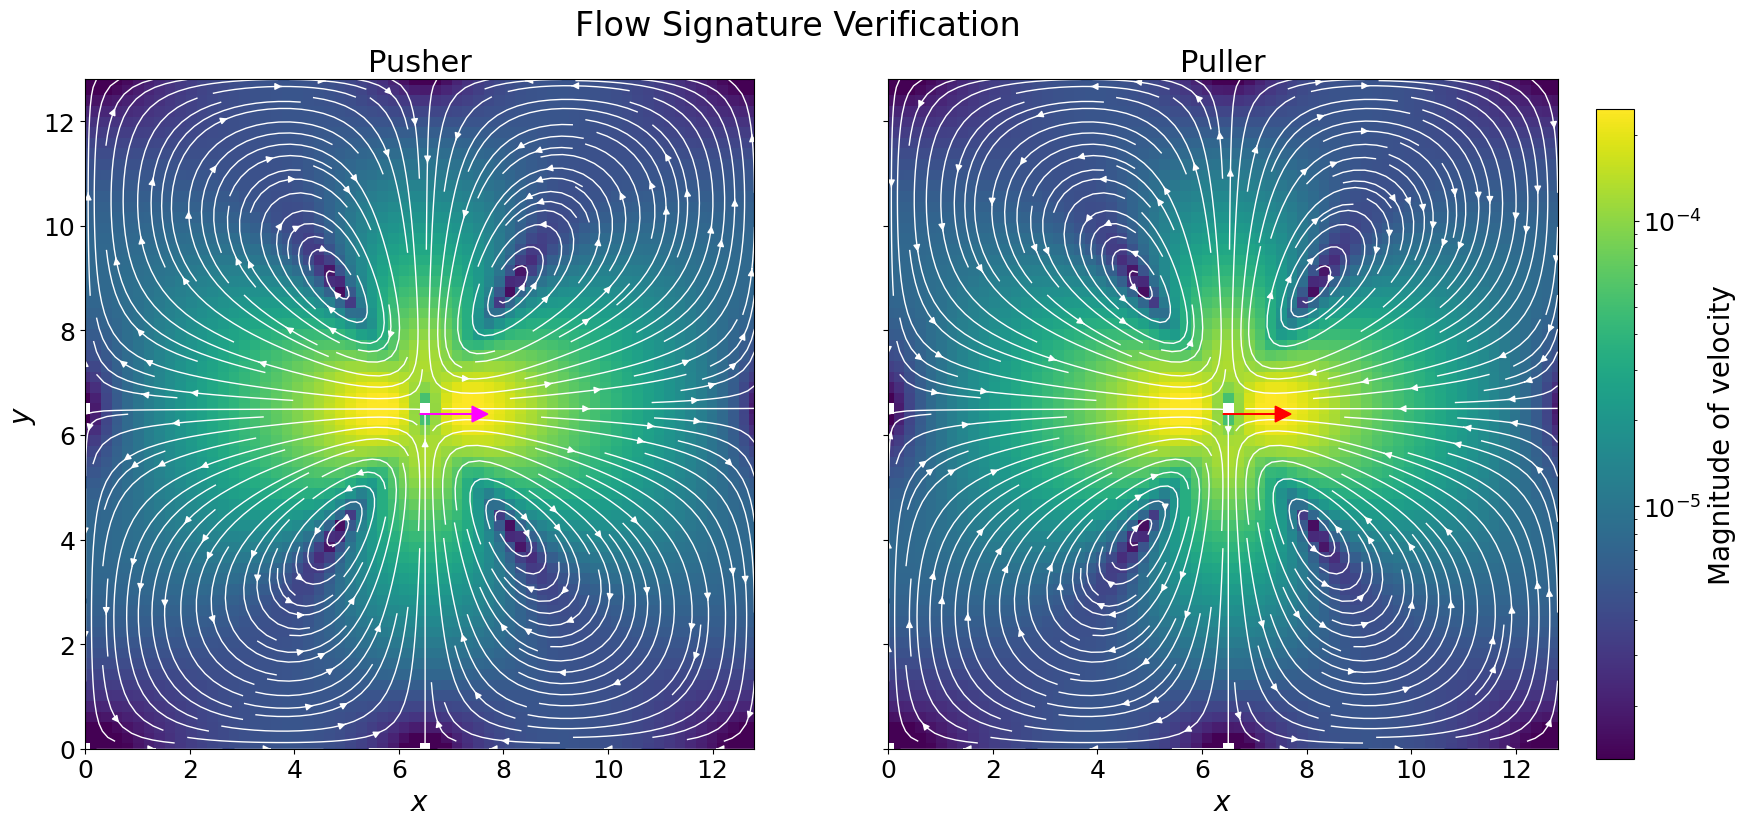

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(19, 10), sharey=True)

# Colormap settings: Shared LogScale magnitude colormap
norm = mcolors.LogNorm(vmin=1.3e-6, vmax=2.46e-4)
cmap = plt.get_cmap('viridis')

# Common labels
for ax in axes:
    ax.set_xlabel('$x$')
    ax.set_aspect('equal', adjustable='box')
axes[0].set_ylabel('$y$')

# Left: PUSHER
ax = axes[0]
ax.set_title("Pusher")
# Magnitude pcolormesh
pcm = ax.pcolormesh(X_plot, Y_plot, mag_pusher.T, norm=norm, cmap=cmap, shading='auto')
# Streamlines: White lines density set to visualize cells
ax.streamplot(X_plot, Y_plot, np.array(u_grid_pusher[0]).T, np.array(u_grid_pusher[1]).T, 
              color='white', density=2.0, linewidth=1.0)
# Swimmer Arrow: Magenta horizontal arrow at (6.4, 6.4)
ax.arrow(6.4, 6.4, 1.0, 0.0, color='magenta', head_width=0.3, head_length=0.3, zorder=10)
ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)

# Right: PULLER
ax = axes[1]
ax.set_title("Puller")
# Magnitude pcolormesh
pcm = ax.pcolormesh(X_plot, Y_plot, mag_puller.T, norm=norm, cmap=cmap, shading='auto')
# Streamlines
ax.streamplot(X_plot, Y_plot, np.array(u_grid_puller[0]).T, np.array(u_grid_puller[1]).T, 
              color='white', density=2.0, linewidth=1.0)
# Swimmer Arrow: Red-orange horizontal arrow at (6.4, 6.4)
ax.arrow(6.4, 6.4, 1.0, 0.0, color='red', head_width=0.3, head_length=0.3, zorder=10)
ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)

# SHARED Colorbar on the far right
# Adjust main plots to make room
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.65]) # [left, bottom, width, height]
fig.colorbar(pcm, cax=cbar_ax, label='Magnitude of velocity')

plt.suptitle("Flow Signature Verification", y=0.9)
plt.savefig(f"flow_signature_verification.png", dpi=300, bbox_inches="tight")
plt.show()

### Single Swimmer Far-field Decay Check

In [81]:
# --- 1. Expand domain to minimize periodic ghost interference ---
Lx, Ly, Lz = 32.0, 32.0, 32.0
Nx, Ny, Nz = 128, 128, 128
eps = 0.5

# Build solver for the larger domain
solve_stationary_fn, nbr_fn = build_quasi2d_stokes_solver(Lx, Ly, Lz, Nx, Ny, Nz, v0=0.0)

center_pos = jnp.array([[Lx / 2.0, Ly / 2.0]])
horiz_angle = jnp.array([0.0])
sigmas_pusher = jnp.array([1.0])

nbr_state = nbr_fn.allocate(center_pos)
_, _, u_grid_pusher = solve_stationary_fn(center_pos, horiz_angle, sigmas_pusher, nbr_state.idx)

# --- 2. Extract the 1D Slice ---
x = np.linspace(0, Lx, Nx, endpoint=False)

# Calculate magnitude over the whole 2D grid, then slice at y = 16 (index Ny // 2)
mag_U = np.sqrt(np.array(u_grid_pusher[0])**2 + np.array(u_grid_pusher[1])**2)
U_slice = mag_U[:, Ny // 2]

# --- 3. Filter for the Goldilocks Zone ---
# We look only at the right side of the swimmer to avoid duplicate symmetric points
r = x - (Lx / 2.0) 
valid_mask = (r > 4.0 * eps) & (r < Lx / 4.0)

r_valid = r[valid_mask]
U_valid = U_slice[valid_mask]

# --- 4. Log-Log Linear Regression ---
log_r = np.log10(r_valid)
log_U = np.log10(U_valid)
slope, intercept, r_value, p_value, std_err = linregress(log_r, log_U)

print(f"Calculated Decay Exponent (Slope) along y=16: {slope:.3f}")
print(f"R-squared of fit: {r_value**2:.4f}")

Calculated Decay Exponent (Slope) along y=16: -1.969
R-squared of fit: 0.9988


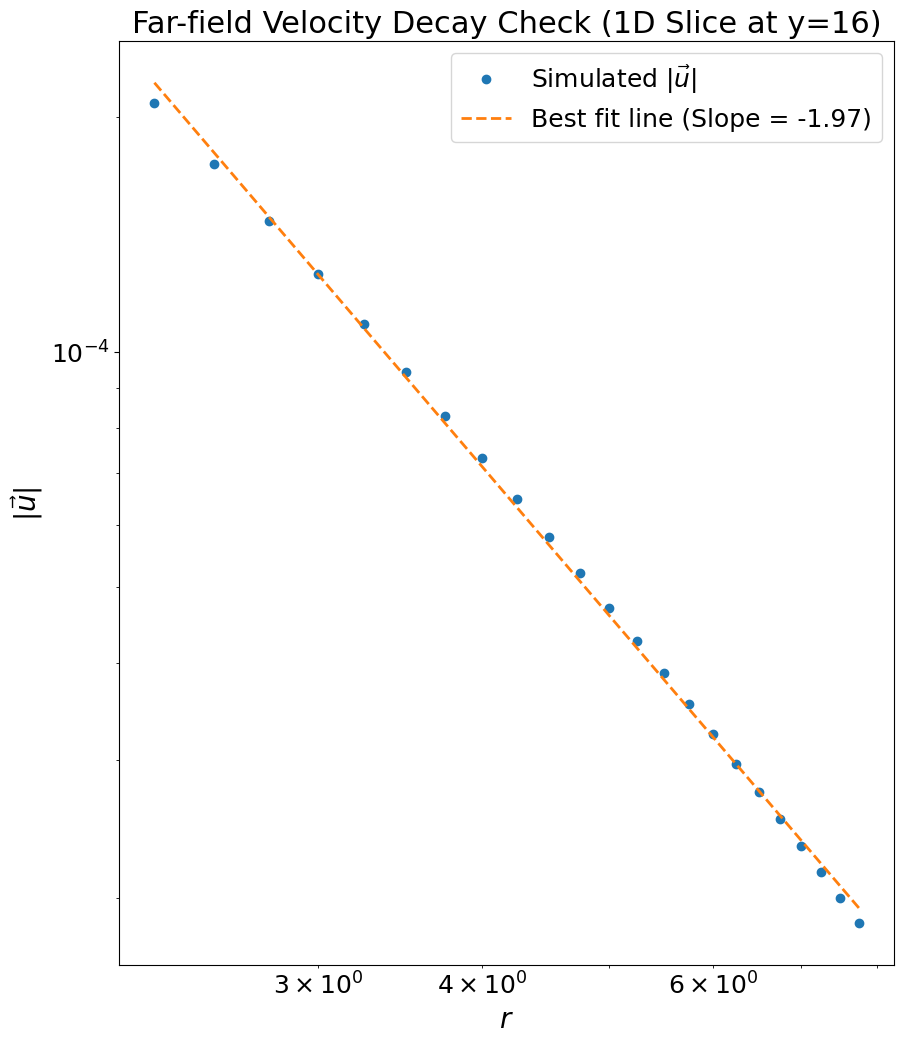

In [82]:
# --- 5. Plotting ---
plt.figure(figsize=(10, 12))

plt.plot(r_valid, U_valid, 'o', label=r'Simulated $|\vec{u}|$')

# Plot the theoretical fit
theoretical_U = (10**intercept) * (r_valid**slope)
plt.plot(r_valid, theoretical_U, '--', linewidth=2, 
         label=f'Best fit line (Slope = {slope:.2f})')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$r$')
plt.ylabel(r'$|\vec{u}|$')
plt.title('Far-field Velocity Decay Check (1D Slice at y=16)')
plt.legend()

plt.savefig(f"far_field_decay_verification.png", dpi=300, bbox_inches="tight")
plt.show()

### Active Brownian Particle Check

In [91]:
def build_abp_test_trajectory(Lx, Ly, dt, solve_flow_fn, sigmas, v0=0.5, Dr=0.01):
    """
    Returns a JIT-compiled function that simulates swimmer trajectories over time using 
    active self-propulsion, steric repulsion, rotational diffusion, AND hydrodynamic coupling.

    Parameters
    -----------
    Lx, Ly : Floats
        Dimensions of the simulation domain
    dt : Float
        Time-step
    solve_flow_fn : JIT-compiled function
        Returns linear and angular velocity of a rigid particle due to background flow, 
        and velocity flow field.
    sigmas : Array, shape (N, )
        Dipole strength of all swimmers, positive for pusher, negative for puller.
    v0 : Float
        Self-propulsion velocity of all swimmers (share the same value)
    Dr : Float
        Rotational diffusivity of all swimmers (share the same value)

    Returns
    --------
    wrapper_simulation : JIT-compiled function
        A function which computes the trajectory (positions and angles) of 
        all swimmers over time.
    """
    
    @jax.jit(static_argnames=['num_steps'])
    def wrapper_simulation(initial_positions, initial_angles, nbrs_init, num_steps, prng_key):
        """
        The function which computes the trajectory (positions and orientations) of 
        all swimmers over time.
    
        Parameters
        -----------
        initial_positions : Array, shape (N, 2)
            Initial (x, y) coordinates of all swimmers
        initial_angles : Array, shape (N, )
            Initial orientation, as measured from x-axis, of all swimmers
        nbrs_init : jax_md.partition.NeighborList
            The initial state of the spatial neighbor list, generated prior to the 
            simulation loop via `neighbor_fn.allocate(initial_positions)`. This 
            state tracks local interaction pairings and is dynamically updated inside.
        num_steps : Integer
            Number of timesteps of the simulation
        prng_key: jax.Array
            Starting pseudo-random number generator key
    
        Returns
        --------
        trajectory : tuple of 2 elements
            1st element is the history of positions, a JAX array of shape 
            (num_steps, N, 2).
            2nd element is the history of orientations, a JAX array of shape 
            (num_steps, N).
        """
        def scan_step(carry, _):
            """
            Helper function to be used as an argument for jax.lax.scan. This function 
            will be iterated to update the positions and angles of the swimmers.
        
            Parameters
            -----------
            carry : tuple
                Current (x, y) positions of all swimmers, current orientation of all 
                swimmers, current random number generator key, and current neighbor list.
        
            Returns
            --------
            next_carry : tuple
                The value of carry to be used in the next iteration of scan_step.
            outputs : tuple
                The data from the current timestep to be saved, which is (x, y) 
                positions and orientations of all swimmers.
            """
            pos, current_angles, key, nbrs = carry
            
            # 1. Update Neighbor List
            nbrs = nbrs.update(pos)
            
            # 2. Extract sparse neighbor indices and feed them to the solver
            u_fluid = 0
            omega_fluid = 0

            # 3. Update positions (Active Propulsion + Background Flow)
            px = jnp.cos(current_angles)
            py = jnp.sin(current_angles)
            p = jnp.stack([px, py], axis=-1)
            
            next_pos = pos + (v0 * p + u_fluid) * dt
            next_pos = next_pos % jnp.array([Lx, Ly])

            # 4. Update angles
            key, subkey = jax.random.split(key)
            noise = jax.random.normal(subkey, shape=current_angles.shape)
            
            next_angles = current_angles + jnp.sqrt(2.0 * Dr * dt) * noise + omega_fluid * dt
            next_angles = next_angles % (2.0 * jnp.pi)
            
            next_carry = (next_pos, next_angles, key, nbrs)
            outputs = (pos, current_angles)
            return next_carry, outputs

        init_state = (initial_positions, initial_angles, prng_key, nbrs_init)
        _, trajectory = jax.lax.scan(scan_step, init_state, None, length=num_steps)
        
        return trajectory

    return wrapper_simulation

In [92]:
# --- 1. Simulation Parameters ---
# Use a massive domain to simulate a dilute suspension and avoid steric collisions
Lx, Ly, Lz = 200.0, 200.0, 32.0 
Nx, Ny, Nz = 32, 32, 32  # Fluid grid resolution (unused since sigmas=0, kept for solver)
N = 1000
dt = 0.1
Dr = 0.01
total_time = int(20 / Dr)
num_steps = int(total_time / dt)
v0 = 0.5

sigmas_zero = jnp.zeros(N)

# --- 2. Initialization ---
prng_key = jax.random.PRNGKey(42)
key_pos, key_ang, sim_key = jax.random.split(prng_key, 3)

initial_positions = jax.random.uniform(key_pos, (N, 2), minval=0.0, maxval=Lx)
initial_angles = jax.random.uniform(key_ang, (N,), minval=0.0, maxval=2.0*jnp.pi)

solve_flow_fn, neighbor_fn = build_quasi2d_stokes_solver(
    Lx, Ly, Lz, Nx, Ny, Nz, mu=1.0, eps=0.5, v0=v0
)

run_simulation = build_abp_test_trajectory(
    Lx, Ly, dt, solve_flow_fn, sigmas=sigmas_zero, v0=v0, Dr=Dr
)

nbrs_init = neighbor_fn.allocate(initial_positions)

# --- 3. Execute Simulation ---
print(f"Simulating {N} ABPs for {num_steps} steps to capture ballistic-to-diffusive crossover...")
pos_history, angle_history = run_simulation(
    initial_positions, initial_angles, nbrs_init, num_steps, sim_key
)

pos_history = np.array(pos_history)
angle_history = np.array(angle_history)

# --- 4. Kinematic Unwrapping & MSD/MSAD Calculations ---
time_array = np.arange(num_steps) * dt

# A. Angles (MSAD)
unwrapped_angles = np.unwrap(angle_history, axis=0)
angular_displacement = unwrapped_angles - unwrapped_angles[0, :]
msad = np.mean(angular_displacement**2, axis=1)

# B. Positions (MSD)
# Calculate step-by-step displacements
dp = pos_history[1:] - pos_history[:-1]

# Apply minimum image convention to remove PBC jumps
dp_x = dp[..., 0] - Lx * np.round(dp[..., 0] / Lx)
dp_y = dp[..., 1] - Ly * np.round(dp[..., 1] / Ly)

# Cumulatively sum the true steps to get continuous trajectories
unwrapped_x = np.vstack([np.zeros((1, N)), np.cumsum(dp_x, axis=0)])
unwrapped_y = np.vstack([np.zeros((1, N)), np.cumsum(dp_y, axis=0)])

msd = np.mean(unwrapped_x**2 + unwrapped_y**2, axis=1)

# --- 5. Theoretical Curves ---
# MSAD Theory
theory_msad = 2.0 * Dr * time_array

# Exact 2D ABP MSD Theory
theory_msd_exact = (2.0 * v0**2 / Dr**2) * (Dr * time_array + np.exp(-Dr * time_array) - 1.0)

# Asymptotes for visualization
theory_msd_ballistic = v0**2 * time_array**2
theory_msd_diffusive = (2.0 * v0**2 / Dr) * time_array

Simulating 1000 ABPs for 20000 steps to capture ballistic-to-diffusive crossover...


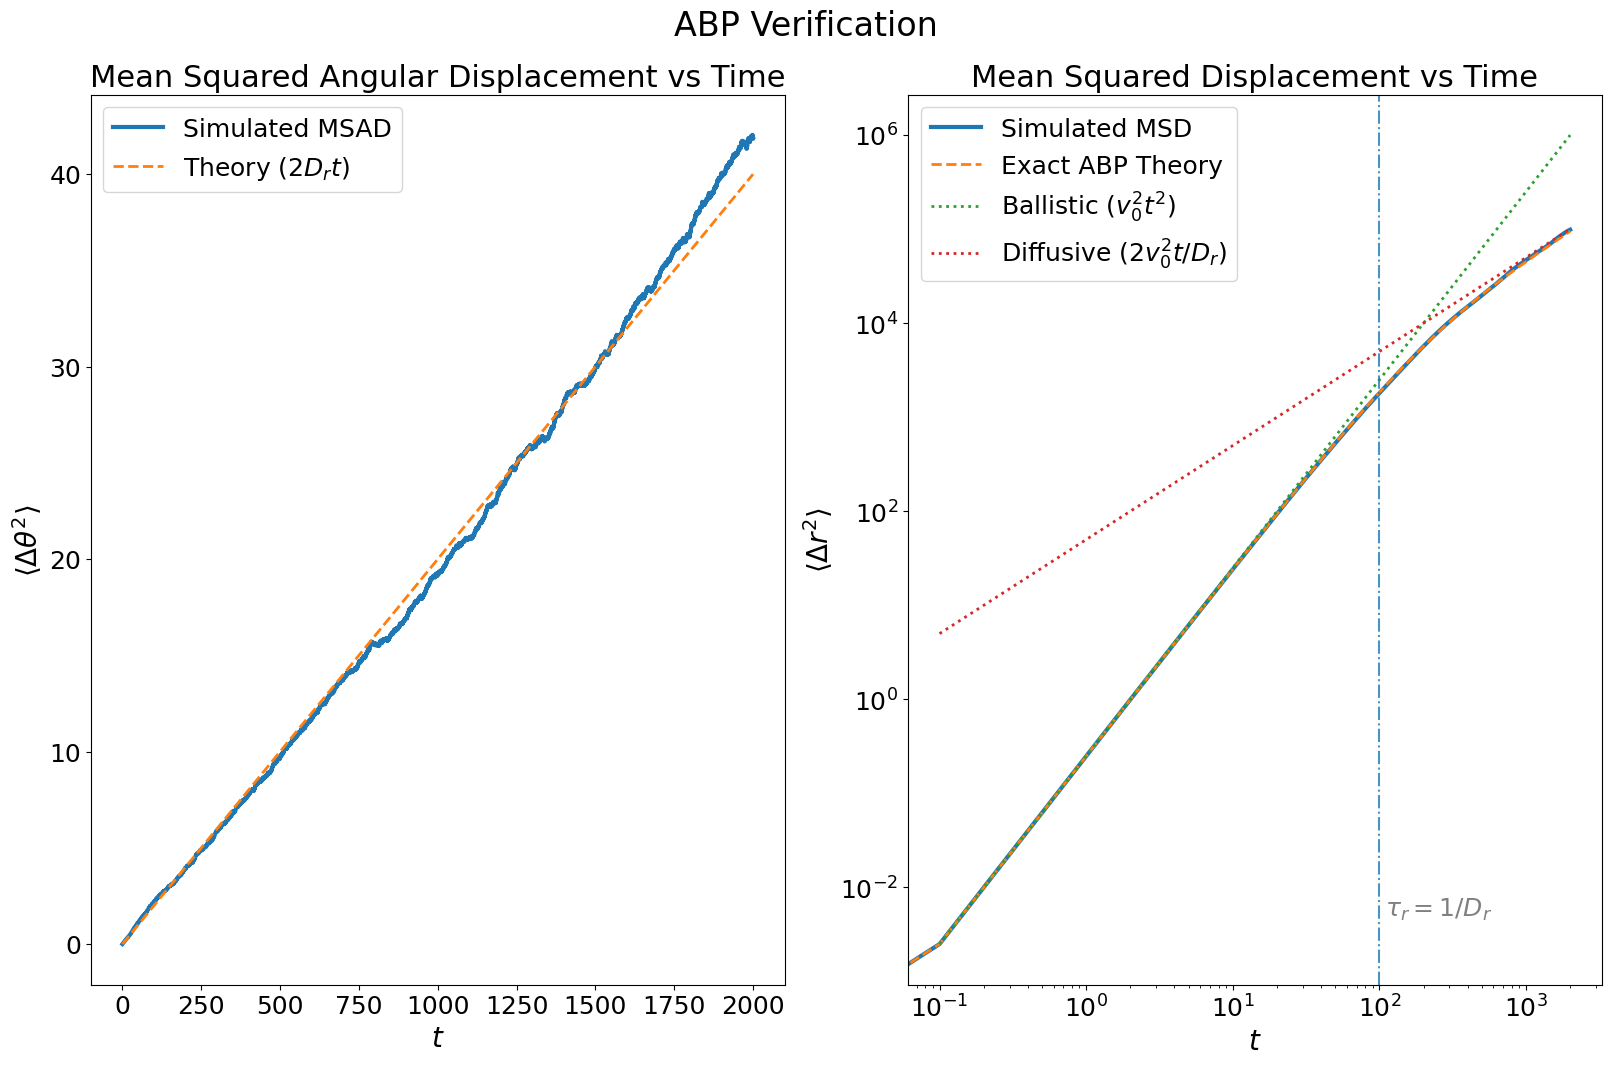

In [93]:
# --- 6. Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10), layout='constrained')

# Left: MSAD (Linear Scale)
ax1.plot(time_array, msad, '-', linewidth=3, label='Simulated MSAD')
ax1.plot(time_array, theory_msad, '--', linewidth=2, label=f'Theory ($2D_r t$)')
ax1.set_xlabel('$t$')
ax1.set_ylabel('$\\langle \\Delta\\theta^2 \\rangle$')
ax1.set_title('Mean Squared Angular Displacement vs Time')
ax1.legend()

# Right: MSD (Log-Log Scale to show slope transition)
ax2.plot(time_array, msd, '-', linewidth=3, label='Simulated MSD')
ax2.plot(time_array, theory_msd_exact, '--', linewidth=2, label='Exact ABP Theory')

# Plot the asymptotes, avoiding the t=0 point for log scale
valid_t = time_array > 0
ax2.plot(time_array[valid_t], theory_msd_ballistic[valid_t], ':', linewidth=2, label='Ballistic ($v_0^2 t^2$)')
ax2.plot(time_array[valid_t], theory_msd_diffusive[valid_t], ':', linewidth=2, label='Diffusive ($2 v_0^2 t / D_r$)')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('$t$')
ax2.set_ylabel('$\\langle \\Delta r^2 \\rangle$')
ax2.set_title('Mean Squared Displacement vs Time')
ax2.legend()

# Highlight the crossover timescale
crossover_time = 1.0 / Dr
ax2.axvline(crossover_time, linestyle='-.', alpha=0.8)
ax2.text(crossover_time * 1.1, np.min(msd[valid_t]) * 2, f'$\\tau_r = 1/D_r$', color='gray')

plt.suptitle("ABP Verification", y=1.05)
plt.savefig(f"abp_verification.png", dpi=300, bbox_inches="tight")
plt.show()

### Periodic Boundary Condition Check

In [105]:
# --- 1. Simulation Parameters ---
Lx, Ly, Lz = 32.0, 32.0, 32.0
Nx, Ny, Nz = 32, 32, 32 
dt = 0.1
total_time = 10 # Enough time to cover a distance of 5.0
num_steps = int(total_time / dt)  
Dr = 0.0        # Turn off rotational noise completely
sigmas = jnp.array([0.0]) # Turn off hydrodynamics to prevent artificial grid self-vorticity

# --- 2. Initialization ---
prng_key = jax.random.PRNGKey(42)
_, _, sim_key = jax.random.split(prng_key, 3)

# Start near the right boundary, pointing precisely along the positive x-axis
initial_positions = jnp.array([[30.0, Ly / 2.0]])
initial_angles = jnp.array([0.0])

# Build solver and trajectory generator
solve_flow_fn, neighbor_fn = build_quasi2d_stokes_solver(
    Lx, Ly, Lz, Nx, Ny, Nz, v0=v0
)

run_simulation = build_trajectory_generator(
    Lx, Ly, dt, solve_flow_fn, sigmas=sigmas, v0=v0, Dr=Dr
)

nbrs_init = neighbor_fn.allocate(initial_positions)

# --- 3. Execute Simulation ---
print("Running PBC crossing test...")
pos_history, angle_history = run_simulation(
    initial_positions, initial_angles, nbrs_init, num_steps, sim_key
)

pos_history = np.array(pos_history)
angle_history = np.array(angle_history)

time_array = np.arange(num_steps) * dt
x_coords = pos_history[:, 0, 0]
angles = angle_history[:, 0]

Running PBC crossing test...


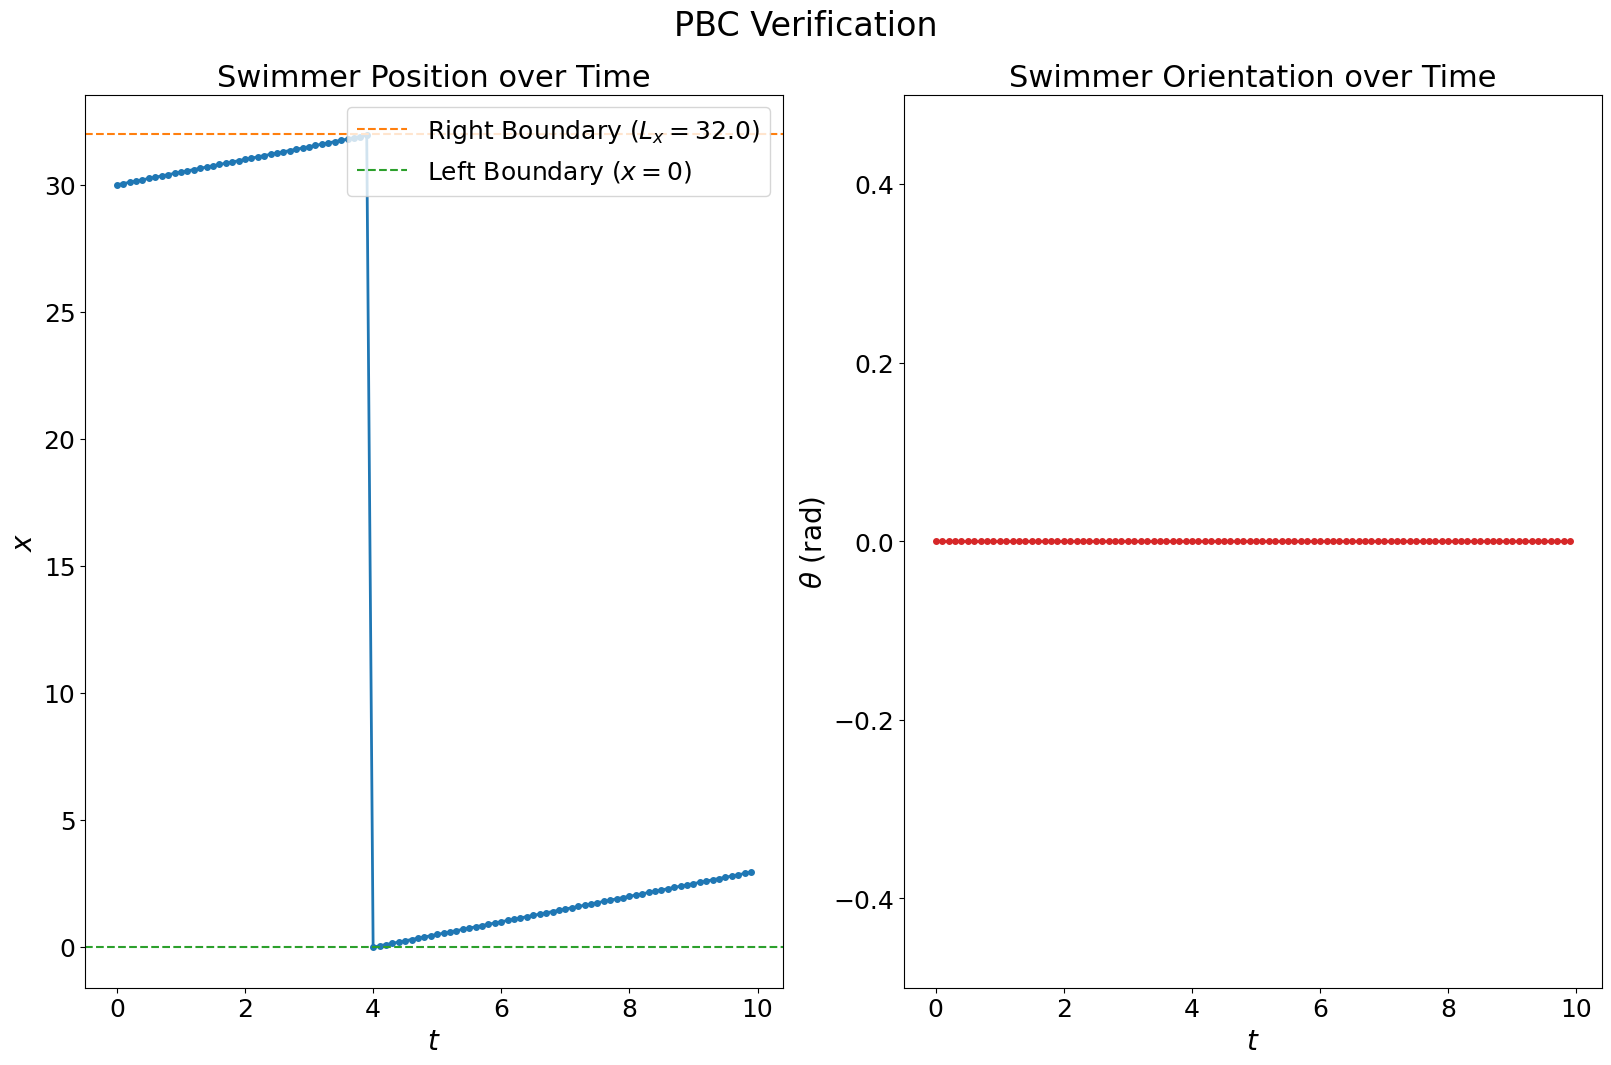

In [107]:
# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10), layout='constrained')

# Plot 1: X-Coordinate over time (should show a sawtooth pattern)
ax1.plot(time_array, x_coords, 'o-', linewidth=2, markersize=4)
ax1.axhline(Lx, linestyle='--', label=f'Right Boundary ($L_x={Lx}$)', color='C1')
ax1.axhline(0, linestyle='--', label='Left Boundary ($x=0$)', color='C2')
ax1.set_xlabel('$t$')
ax1.set_ylabel(r'$x$')
ax1.set_title('Swimmer Position over Time')
ax1.legend(loc='upper right', bbox_to_anchor=(1, 1))

# Plot 2: Orientation over time (should be a perfectly flat line)
ax2.plot(time_array, angles, 'o-', linewidth=2, markersize=4, color='C3')
ax2.set_ylim(-0.5, 0.5) # Zoom in to prove it isn't fluctuating
ax2.set_xlabel('$t$')
ax2.set_ylabel('$\\theta$ (rad)')
ax2.set_title('Swimmer Orientation over Time')

plt.suptitle('PBC Verification', y=1.05)
plt.savefig(f"pbc_verification.png", dpi=300, bbox_inches="tight")
plt.show()

### Self-advection Check

In [108]:
# --- 1. Simulation Parameters ---
Lx, Ly, Lz = 32.0, 32.0, 32.0
Nx, Ny, Nz = 32, 32, 32
dx = Lx / Nx

# Turn off active motion (v0=0), turn ON hydrodynamics (sigma=1)
v0 = 0.0
sigmas = jnp.array([1.0])
horiz_angle = jnp.array([0.0])

# Build solver
solve_flow_fn, nbr_fn = build_quasi2d_stokes_solver(Lx, Ly, Lz, Nx, Ny, Nz, v0=v0)

# --- 2. Sub-Grid Sweeping ---
num_test_points = 100
# Sweep from 0 to dx (one full grid cell)
subgrid_offsets = np.linspace(0, dx, num_test_points)

u_self_x = np.zeros(num_test_points)
u_self_y = np.zeros(num_test_points)
omega_self = np.zeros(num_test_points)

print("Sweeping sub-grid positions to measure self-advection...")

for i, offset in enumerate(subgrid_offsets):
    # Offset Y slightly (e.g., 0.33 * dx) to break perfect horizontal symmetry
    # This exposes the maximum possible grid artifact
    test_pos = jnp.array([[Lx / 2.0 + offset, Ly / 2.0 + dx * 0.33]])
    
    nbr_state = nbr_fn.allocate(test_pos)
    
    # Evaluate flow EXACTLY at the particle's center
    u_fluid, omega_fluid, _ = solve_flow_fn(test_pos, horiz_angle, sigmas, nbr_state.idx)
    
    u_self_x[i] = float(u_fluid[0, 0])
    u_self_y[i] = float(u_fluid[0, 1])
    omega_self[i] = float(omega_fluid[0])

print(f"Max Spurious Velocity (u_x):   {np.max(np.abs(u_self_x)):.2e}")
print(f"Max Spurious Velocity (u_y):   {np.max(np.abs(u_self_y)):.2e}")
print(f"Max Spurious Vorticity (omega): {np.max(np.abs(omega_self)):.2e}")

Sweeping sub-grid positions to measure self-advection...
Max Spurious Velocity (u_x):   1.89e-18
Max Spurious Velocity (u_y):   8.91e-19
Max Spurious Vorticity (omega): 1.53e-06


### Head-on Collision Check

In [11]:
# --- 1. Simulation Parameters ---
grid_count = 64
Lx, Ly, Lz = 32.0, 32.0, 32.0
Nx, Ny, Nz = grid_count, grid_count, grid_count
dt = 0.05
num_steps = 200
Dr = 0.0
dimension = 2
eps = 0.5
sigma_rep = 2*eps
r_cutoff = 3 * sigma_rep

# Calculate the maximum possible number of neighbors based on area packing
tracking_radius = r_cutoff + eps  # e.g., 3.0 + 0.5 = 3.5
particle_radius = 0.5 * sigma_rep # e.g., 0.5

if dimension == 2:
    # Max particles in tracking circle (assuming ~90% optimal hexagonal packing)
    max_neighbors = int(0.9 * (tracking_radius / particle_radius)**2)
else: # 3D
    # Max particles in tracking sphere (assuming ~74% optimal spherical packing)
    max_neighbors = int(0.74 * (tracking_radius / particle_radius)**3)

# Turn off hydrodynamic dipoles to isolate pure steric repulsion
sigmas = jnp.zeros(2)

# --- 2. Initialization ---
prng_key = jax.random.PRNGKey(42)
_, _, sim_key = jax.random.split(prng_key, 3)

# Place Swimmer 1 at x=12 facing right, Swimmer 2 at x=20 facing left
initial_positions = jnp.array([
    [12.0, Ly / 2.0], 
    [20.0, Ly / 2.0]
])
initial_angles = jnp.array([0.0, jnp.pi])

# Build solver and trajectory generator
solve_flow_fn, neighbor_fn = build_quasi2d_stokes_solver(
    Lx, Ly, Lz, Nx, Ny, Nz
)

run_simulation = build_trajectory_generator(
    Lx, Ly, dt, solve_flow_fn, sigmas=sigmas, Dr=Dr
)

# Allocate the list with the strict mathematical upper limit
nbrs_init = neighbor_fn.allocate(initial_positions, extra_capacity=max_neighbors)

# --- 3. Execute Simulation ---
print("Running head-on collision test...")
pos_history, angle_history = run_simulation(
    initial_positions, initial_angles, nbrs_init, num_steps, sim_key
)

pos_history = np.array(pos_history)
time_array = np.arange(num_steps) * dt

# Extract X coordinates for both swimmers
x1 = pos_history[:, 0, 0]
x2 = pos_history[:, 1, 0]

# Calculate the distance between them over time
distance = np.abs(x2 - x1)

# Verify the Stall Distance
stall_distance = distance[-1]
print(f"Final stall distance between swimmers: {stall_distance:.4f}")

Running head-on collision test...
Final stall distance between swimmers: 1.2945


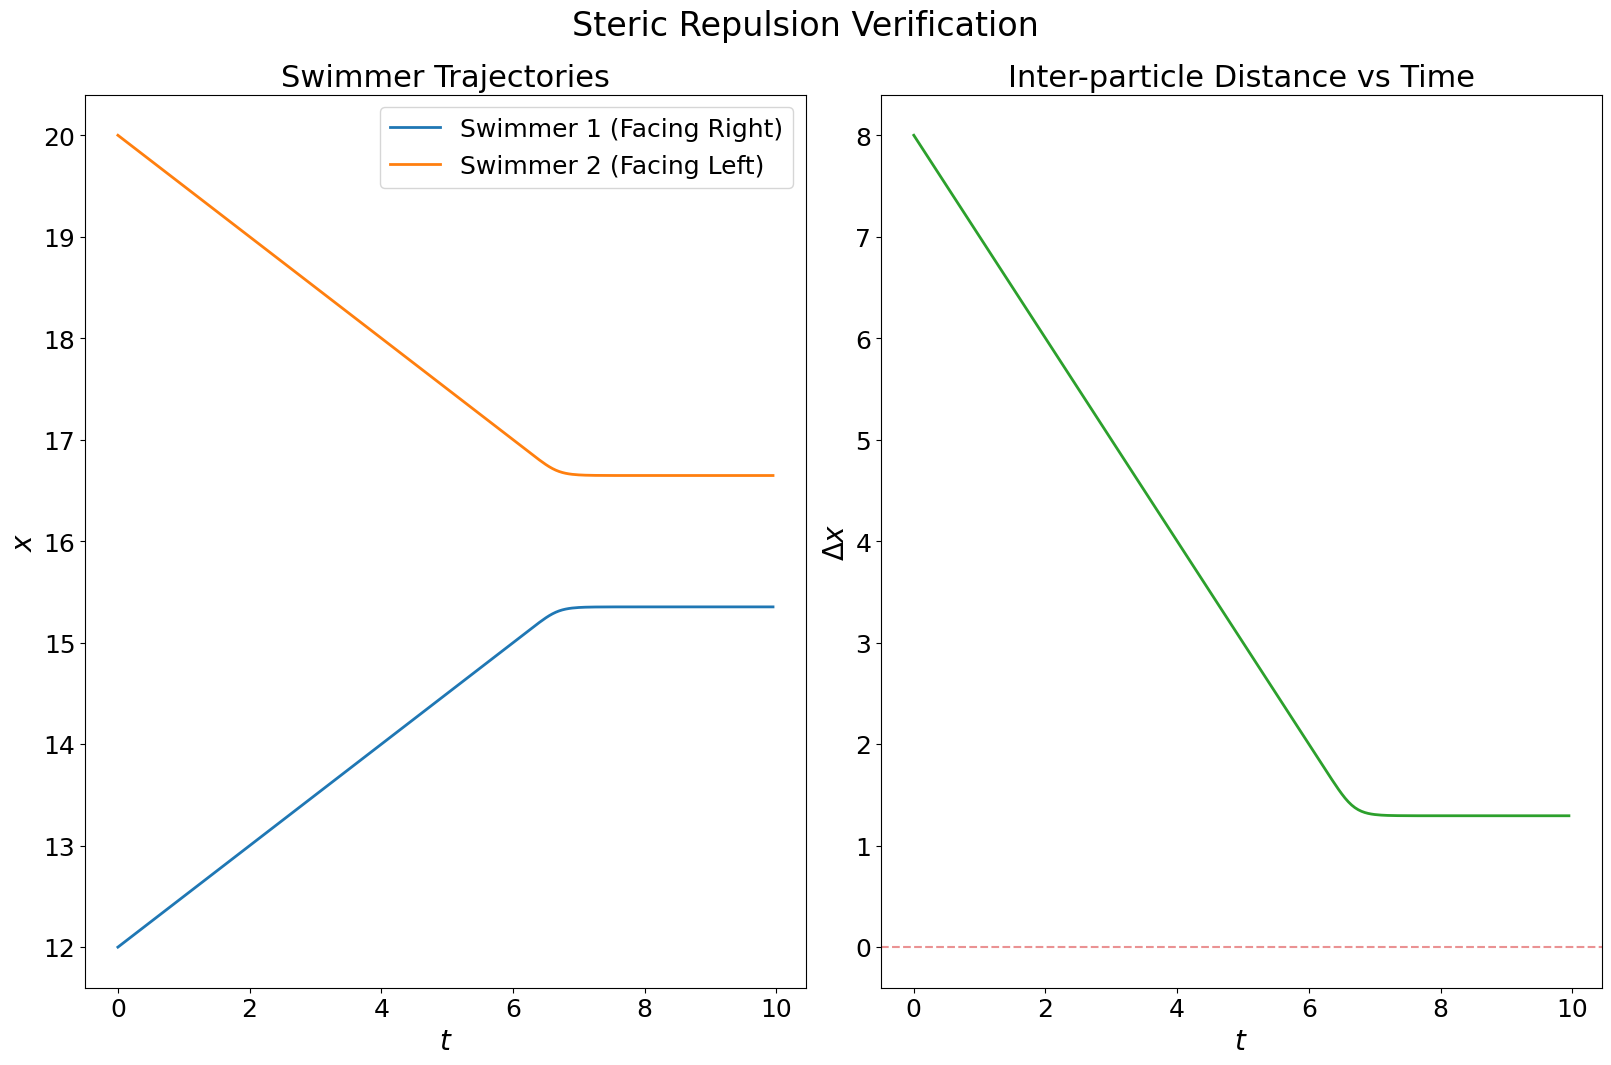

In [14]:
# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10), layout='constrained')

# Plot 1: Trajectories (X-coordinate vs Time)
ax1.plot(time_array, x1, '-', linewidth=2, label='Swimmer 1 (Facing Right)')
ax1.plot(time_array, x2, '-', linewidth=2, label='Swimmer 2 (Facing Left)')
ax1.set_xlabel('$t$')
ax1.set_ylabel('$x$')
ax1.set_title('Swimmer Trajectories')
ax1.legend()

# Plot 2: Inter-particle Distance vs Time
ax2.plot(time_array, distance, '-', linewidth=2, color='C2')
ax2.axhline(0, color='C3', linestyle='--', alpha=0.5)
ax2.set_xlabel('$t$')
ax2.set_ylabel('$\\Delta x$')
ax2.set_title('Inter-particle Distance vs Time')

plt.suptitle('Steric Repulsion Verification', y=1.05)
plt.savefig(f"steric_repulsion_verification.png", dpi=300, bbox_inches="tight")
plt.show()

### Two-Swimmer Hydrodynamic Scattering Check

In [15]:
# --- 1. Simulation Parameters ---
Lx, Ly, Lz = 10.0, 10.0, 1.0
Nx, Ny, Nz = 64, 64, 4
dt = 0.05
num_steps = 350
Dr = 0.0          # No rotational noise to clearly see the hydrodynamic alignment
sigma_val = 3.0   # Positive value for pushers
eps = 0.5
sigma_rep = 2*eps
r_cutoff = 3*sigma_rep
dimension = 2

# --- 2. Initial Conditions ---
# Left pusher starting at x=3, pointing upper-right (60 degrees)
# Right pusher starting at x=7, pointing upper-left (120 degrees)
initial_positions = jnp.array([
    [3.0, 2.0],
    [7.0, 2.0]
])
initial_angles = jnp.array([jnp.pi / 3.0, 2.0 * jnp.pi / 3.0])
sigmas = jnp.array([sigma_val, sigma_val])

# Instantiate the swimmers
swimmers = AxisymmetricSwimmers2D(initial_positions, initial_angles, sigmas)

# --- 3. Build Solvers and Initialize ---
print("Compiling solvers...")
solve_flow_fn, neighbor_fn = build_quasi2d_stokes_solver(
    Lx, Ly, Lz, Nx, Ny, Nz
)

simulate_fn = build_trajectory_generator(
    Lx, Ly, dt, solve_flow_fn, swimmers.dipole_strengths, Dr=Dr
)

# Calculate the maximum possible number of neighbors based on area packing
tracking_radius = r_cutoff + eps  
particle_radius = 0.5 * sigma_rep

if dimension == 2:
    # Max particles in tracking circle (assuming ~90% optimal hexagonal packing)
    max_neighbors = int(0.9 * (tracking_radius / particle_radius)**2)
else: # 3D
    # Max particles in tracking sphere (assuming ~74% optimal spherical packing)
    max_neighbors = int(0.74 * (tracking_radius / particle_radius)**3)

# Allocate initial neighbor list
nbrs_init = neighbor_fn.allocate(swimmers.positions, extra_capacity=max_neighbors)

# --- 4. Run the Simulation ---
print(f"Simulating {num_steps} steps...")
prng_key = jax.random.PRNGKey(42)
traj_positions, traj_angles = simulate_fn(
    swimmers.positions, swimmers.angles, nbrs_init, num_steps, prng_key
)

# Block until computation finishes (JAX is asynchronous)
traj_positions = jax.device_get(traj_positions)
traj_angles = jax.device_get(traj_angles)
print("Simulation complete.")

Compiling solvers...
Simulating 350 steps...
Simulation complete.


Rendering animation...
Animation saved successfully as 'pusher_scattering.mp4'.


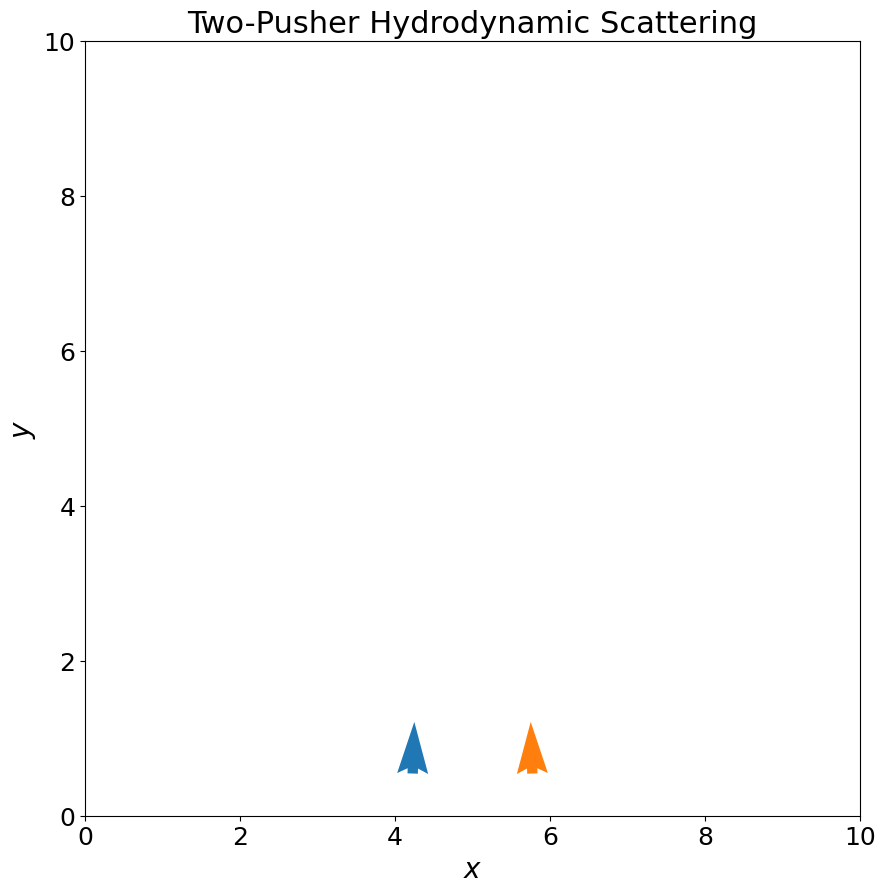

In [18]:
# --- 5. Generate and Export Animation ---
print("Rendering animation...")
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)
ax.set_aspect('equal')
ax.set_title("Two-Pusher Hydrodynamic Scattering")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

# We use a quiver plot to visualize the swimmers and their orientations
# Initial placeholder quiver
Q = ax.quiver(
    traj_positions[0, :, 0], traj_positions[0, :, 1],
    jnp.cos(traj_angles[0]), jnp.sin(traj_angles[0]),
    color=['C0', 'C1'], scale=15, width=0.015
)

def update(frame):
    # Update positions
    x = traj_positions[frame, :, 0]
    y = traj_positions[frame, :, 1]
    
    # Update orientation vectors
    u = jnp.cos(traj_angles[frame])
    v = jnp.sin(traj_angles[frame])
    
    Q.set_offsets(jnp.c_[x, y])
    Q.set_UVC(u, v)
    return Q,

ani = animation.FuncAnimation(
    fig, update, frames=num_steps, interval=50, blit=True
)

# Export as MP4
writer = animation.FFMpegWriter(fps=num_steps/10, bitrate=1800)
ani.save("pusher_scattering.mp4", writer=writer)
print("Animation saved successfully as 'pusher_scattering.mp4'.")

### Dipole Strength Invariance Test

In [20]:
# --- 1. Base Simulation Parameters ---
Lx, Ly, Lz = 10.0, 10.0, 1.0
Nx, Ny, Nz = 64, 64, 4
dt = 0.05
num_steps = 300
eps = 0.5         
Dr = 0.0          # Keep rotational noise off for deterministic collisions
sigma_rep = 2*eps
r_cutoff = 3*sigma_rep
dimension = 2

# --- 2. Parameter Sweep Ranges ---
v0_values = [0.5, 1.5]
sigma_values = [1.0, 3.0]

# Initial conditions for a direct head-on collision to force a close encounter
initial_positions = jnp.array([
    [3.0, 5.0],
    [7.0, 5.0]
])

initial_angles = jnp.array([jnp.pi / 3, 2 * jnp.pi / 3])

print(f"{'v0':<5} | {'Sigma':<7} | {'Min Distance':<12}")
print("-" * 30)

# Calculate the maximum possible number of neighbors based on area packing
tracking_radius = r_cutoff + eps  
particle_radius = 0.5 * sigma_rep

if dimension == 2:
    # Max particles in tracking circle (assuming ~90% optimal hexagonal packing)
    max_neighbors = int(0.9 * (tracking_radius / particle_radius)**2)
else: # 3D
    # Max particles in tracking sphere (assuming ~74% optimal spherical packing)
    max_neighbors = int(0.74 * (tracking_radius / particle_radius)**3)

# --- 3. Execution Loop ---
prng_key = jax.random.PRNGKey(42)

for v0 in v0_values:
    # We must rebuild the solvers for each new v0 since it is in the closure
    solve_flow_fn, neighbor_fn = build_quasi2d_stokes_solver(
        Lx, Ly, Lz, Nx, Ny, Nz, mu=1.0, eps=eps, v0=v0
    )
    
    # Allocate initial neighbor list (same for all iterations since positions are static)
    nbrs_init = neighbor_fn.allocate(initial_positions, extra_capacity=max_neighbors)
    
    for sigma_val in sigma_values:
        sigmas = jnp.array([sigma_val, sigma_val])
        swimmers = AxisymmetricSwimmers2D(initial_positions, initial_angles, sigmas)
        
        simulate_fn = build_trajectory_generator(
            Lx, Ly, dt, solve_flow_fn, swimmers.dipole_strengths, v0=v0, Dr=Dr
        )
        
        # Run simulation
        traj_positions, traj_angles = simulate_fn(
            swimmers.positions, swimmers.angles, nbrs_init, num_steps, prng_key
        )
        
        # Block and fetch data
        traj_positions = jax.device_get(traj_positions)
        
        # Calculate the Euclidean distance between the two swimmers at every timestep
        # traj_positions shape is (num_steps, 2, 2)
        delta_r = traj_positions[:, 0, :] - traj_positions[:, 1, :]
        distances = jnp.linalg.norm(delta_r, axis=1)
        
        min_dist = jnp.min(distances)
        
        print(f"{v0:<5.1f} | {sigma_val:<7.1f} | {min_dist:<12.4f}")

print("-" * 30)
print("Sweep complete.")

v0    | Sigma   | Min Distance
------------------------------


C:\Users\leeyz\anaconda3\envs\dip_swim_env\Lib\site-packages\jax\_src\numpy\array_methods.py:125: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


0.5   | 1.0     | 1.4605      
0.5   | 3.0     | 1.4809      
1.5   | 1.0     | 1.4470      
1.5   | 3.0     | 1.4589      
------------------------------
Sweep complete.
